# <center>Breaking Down the Banking Crisis: A Deep Dive into Headline Analysis </center>



# **Background**
---



Silicon Valley Bank, which has been catering to the startups and their investors worldwide, invested a significant portion of its deposits into low-yielding investments such as U.S. Treasurys when the tech industry was experiencing a boom. However, with the Federal Reserve increasing interest rates last year, venture capital funding dwindled, resulting in startups exhausting their cash reserves. To cope with the increasing withdrawals, SVB had to sell off some of its government bonds at a considerable loss as new bond yields surged. Here's a detailed timeline of the events that have unfolded so far.

- Feb. 24: KPMG signs an audit report giving SVB Financial, Silicon Valley Bank’s parent company, a clean bill of health for 2022. That year, the bank’s deposits peaked at the end of the first quarter after surging 86% in 2021. Over the months that followed, though, deposits would decline by $25 billion, or 13%, as the Federal Reserve raised interest rates.

- March 8: Silicon Valley Bank announces it would book a $1.8 billion loss after selling some of its investments to cover increasing withdrawals. The bank says client cash burn has remained elevated, and increased further in February, leaving its deposits at the end of that month lower than it expected. It says it plans to raise \$2.25 billion by selling a mix of common and preferred stock.

- March 10: Shares of SVB are halted Friday morning after a premarket selloff. Soon after, federal regulators announce they have taken control of the bank before it can open. It is the second-biggest bank failure in U.S. history, after Washington Mutual’s collapse during the height of the 2008 financial crisis. The FDIC says customers’ insured deposits would be available Monday. It doesn’t say when uninsured depositors will get their money back.

- March 11-12: Over the weekend, tech startups scramble to line up funding sources for payroll and other day-to-day operations with their deposits locked up in the failed bank.

- March 12: As worries of bank runs spread to other banks, federal regulators on Sunday unveil emergency measures to stem the fallout from Silicon Valley Bank’s failure. They announce they have taken control of a second bank, Signature Bank, making it the third-largest bank failure in U.S. history. Regulators say customers of both banks will get all their money back. They also announce a new lending program for banks.

- March 13: In a televised address, President Biden seeks to restore confidence in the financial system and stresses that the banking system is safe. Shares of First Republic and other regional bank stocks continue to slide.

- March 14: The Justice Department and Securities and Exchange Commission are investigating Silicon Valley Bank’s collapse in separate probes, The Wall Street Journal reports. The Federal Reserve, meanwhile, is rethinking a number of its rules related to midsize banks.

- March 15: Credit Suisse Group sees its shares hit a new low as worries about the financial system spread across the Atlantic. Other European bank stocks take hits, including France’s Société Générale and BNP Paribas and Germany’s Deutsche Bank.

- March 16: Shares of Credit Suisse jump, snapping an eight-session losing streak, after the bank’s loan announcement. First Republic shares also turn positive after the Journal reports that the biggest banks in the U.S. are discussing a joint rescue to shore up the lender’s liquidity. Federal regulators later announce that 11 banks have deposited $30 billion in First Republic.

- March 17: The previous day’s gains are short-lived and First Republic shares plunge again to end their worst week on record, reflecting investors’ worries that the bank’s problems haven’t been fully addressed. Credit Suisse shares also fall, despite the lifeline from the Swiss central bank.


- March 18: UBS Group nears a deal take over Credit Suisse, part of an urgent effort by Swiss and global authorities to restore trust in the banking system, the Journal reports. UBS is the biggest bank by assets in Switzerland and had long been seen as part of any state-backed solution for Credit Suisse, the country’s second-largest bank by assets.

- March 19: UBS agrees to take over rival Credit Suisse for more than $3 billion in a deal engineered by Swiss regulators. The megamerger represents a new global dimension in the banking turmoil set off by Silicon Valley Bank’s collapse.

- March 20: JPMorgan Chase & Co. CEO Jamie Dimon is leading discussions with the chief executives of other big banks about a new effort to stabilize First Republic, the Journal reports. Shares of First Republic continue their slide, closing down 47%.

- March 21: Treasury Secretary Janet Yellen says the federal government could step in to protect depositors at additional banks if regulators see a risk of a run on the banking system. Shares of First Republic jump nearly 30%, leading a rally in regional bank shares.
- March 24: Investors spark a selloff in Deutsche Bank and thrust one of Europe’s most important lenders into the center of concerns about the health of the global financial system.
- March 27: The Federal Deposit Insurance Corp. announces that First Citizens BancShares will acquire the bulk of Silicon Valley Bank’s assets. Shares of regional banks rally.   

# **Objective**
---

We will be extracting finance and banking news headlines from the website https://finviz.com/. Then 
- we will utilize a topic model to detect the events in their early stages: initially, the topic will be an outlier and subsequently gain attention (trending).
- Additionally, we can apply sentiment analysis to assess the market sentiment towards these events.



# **Tasks**
---

## 1. Get data (20%-25%) 

Your team is required to collect a sufficient amount of headlines for the project, which should be submitted along with your notebook. Copying and pasting directly from the website will only result in 20% credit, while scraping the data using Python will earn your team 25% credit.
  - You can get financial news from other news websites (excluding twitter). You also will get additional 5% credit if you scrape the data with python. 
  - You need to collect all news related to the sector of finance/banks. 
  - If you want to improve your results, you can download all news about economics and financial market and label the one related to the banks mannully. With Word2vec features, you can easily set up classification model which can identify news for banks. 


## 2. Clean and preprocess the data (25%)

The team will be responsible for determining the optimal methods for cleaning and preprocessing the data to achieve the highest possible performance in the given tasks.

## 3. Topic Modeling (Early Alarming) (20%)
Your team is tasked with selecting appropriate methods such as LDA, dynamic LDA, or Top2Vec to build topic models for the banking crisis event. It is essential to demonstrate that the results obtained can detect the event early by utilizing visualization tools. You need to present your approach and results in a clear and concise manner. 


## 4. Sentiment Analysis (35%)

Your team is required to select appropriate methods for sentiment analysis to capture the dynamics of market sentiments in the banking sector, or "fear index of bank sector (FIB)".  You should demonstrate your results with the appropriate visualization techniques.
  - Again, you can improve the results by manually labeling news in the training data. This will significantly improve the performance of the model. The grading will be based on the quality of the results. 

# -------Start working now---------

Install package at first

In [162]:
# !pip install stop_words 
# !pip install gensim
# !pip install pyLDAvis
# !pip install tmplot
# !pip install bitermplus
# !pip install nltk
# !pip install wordcloud
# !pip install pyLDAvis
# !pip install yfinance

In [163]:
# !pip install openai --quiet

# 1. Get data (20%-25%) 

In [164]:
import pandas as pd
from stop_words import get_stop_words
import json
import pandas as pd
import numpy as np
from gensim import corpora
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt 
pd.options.plotting.backend = "plotly"
import yfinance as yf

In [165]:
data=pd.read_excel('.\data source\Banking News _20230102-20230331_bloomberg-BFW.xlsx')

df=data.dropna().drop_duplicates()
df['publish time']=pd.to_datetime(df['publish time'])
df.sort_values(by=['publish time'], inplace=True, ascending=True)
df.set_index(df['publish time'],inplace=True)

# ----print-----
print("data shape in original version ",data.shape)
print(data.head())
print('\n\n')
print("data shape in new version",df.shape)
print(df.head())

data shape in original version  (8306, 3)
                                            headline news source publish time
0  Timing of BOJ YCC Tweak at Risk From Global Co...         BFW   2023-03-31
1  BofA Sees ‘Ample’ Small-Cap Opportunities for ...         BFW   2023-03-31
2  Stoxx Europe 600 Banks, Health Saw Most Upgrad...         BFW   2023-03-31
3  Mexico Net Outstanding Loans Rose Nominal 13.3...         BFW   2023-03-31
4                  *MEXICO FEB. BANK LOANS MXN5.492T         BFW   2023-03-31



data shape in new version (8137, 3)
                                                       headline news source   
publish time                                                                  
2023-01-02    Hedge Fund Align Urges Korean Banks to Boost S...         BFW  \
2023-01-02    Israel’s Smotrich May Adopt Rules Forcing Disc...         BFW   
2023-01-02                  *PRICED: ERSTE €1B 6Y COVERED MS+20         BFW   
2023-01-02    *GAFISA RISES 15% WITH INTENTION TO SELL S

In [166]:
text_data=pd.DataFrame(index=df.index)
text_data['headline_text']=df['headline'] # type: list

print("data shape in text_data version",data.shape)
print(text_data.head())

data shape in text_data version (8306, 3)
                                                  headline_text
publish time                                                   
2023-01-02    Hedge Fund Align Urges Korean Banks to Boost S...
2023-01-02    Israel’s Smotrich May Adopt Rules Forcing Disc...
2023-01-02                  *PRICED: ERSTE €1B 6Y COVERED MS+20
2023-01-02    *GAFISA RISES 15% WITH INTENTION TO SELL STAKE...
2023-01-02    Actis Is Said to Be in Talks to Refinance Min....


In [167]:
fin_svb=pd.read_csv(".\data source\SIVBQ_20230102_20230331.csv")
fin_svb['Date']=pd.to_datetime(fin_svb['Date'])
fin_svb.set_index('Date',inplace=True)
fin_svb.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-01-03,232.169998,235.000000,221.649994,225.220001,225.220001,764645
2023-01-04,230.100006,241.632507,228.710007,240.059998,240.059998,854687
2023-01-05,235.710007,237.389999,222.410004,232.589996,232.589996,985262
2023-01-06,237.119995,248.190002,231.429993,245.789993,245.789993,1017532
2023-01-09,247.960007,254.940002,244.529999,249.429993,249.429993,1102929


In [168]:
svb_dates = fin_svb.index
all_dates = text_data.index.unique()

m=[]
for d in all_dates:
    if d in svb_dates:
        m.append( round(fin_svb.Close.loc[d], 2) )
    else:
        m.append(np.nan)

svb = pd.DataFrame(index=text_data.index.unique())
svb['svb'] = m
svb.fillna(axis=0, method="ffill",inplace=True)
svb

,svb
publish time,
2023-01-02,NaN
2023-01-03,225.22
2023-01-04,240.06
2023-01-05,232.59
2023-01-06,245.79
...,...
2023-03-27,106.04
2023-03-28,0.40
2023-03-29,0.97


# 2. Clean and preprocess the data (25%)

## Exploratory Data analysis

(array([3.000e+00, 2.100e+01, 1.170e+02, 3.150e+02, 5.140e+02, 9.960e+02,
        1.633e+03, 3.676e+03, 8.470e+02, 1.500e+01]),
 array([17. , 22.8, 28.6, 34.4, 40.2, 46. , 51.8, 57.6, 63.4, 69.2, 75. ]),
 <BarContainer object of 10 artists>)

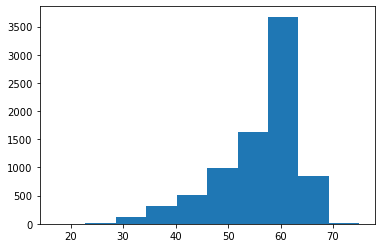

In [169]:
#Exploratory data analysis count the total number of unique words and character length
text_data['Sentence_length'] = text_data['headline_text'].map(str).apply(len)

plt.hist(text_data['Sentence_length'] )

In [170]:
# #Exploratory data analysis count the total number of unique words and character length

# count_string= text_data.headline_text.tolist() #Converting list to dataframe for analysis. 
# count_string2=[]

# for vals in count_string: #Splitting each string into corresponding components for counting 
#     ar_string=0
#     ar_string=vals.split()
    
#     for drvals in ar_string: #Iterating through each word in string and appending to list for further processing. 
        
#         count_string2.append(drvals)

# Gross_no_of_words=len(count_string2) #Determint the total number of words in the text corpus

# vocab_dictionary={} #Create a dictionary to store counts of unique values in 

# for valz in count_string2:  #Iterating through gross no of words and determining total number of each unique word
#     if valz in vocab_dictionary:
#         vocab_dictionary[valz]+=1
#     else:
#         vocab_dictionary[valz]=1

# vocab_dictionary_non_rare = dict((k, v) for k, v in vocab_dictionary.items() if v >= 5) #Create a dictionary for all non rare vocab that occurs more than 5 times        

# No_of_unique_non_rare_terms=len(vocab_dictionary_non_rare.keys()) #Determine number of non rare terms in text corpus 

# List_of_unique_words=set(count_string2)
# No_of_unique_words_stpwrds_included=len(List_of_unique_words) #Determine the total number of unique words in the corpus
# print(f'total number of words in text corpus:{len(count_string2)}')
# print(f'total number of unique words in text corpus rare words removed:{No_of_unique_non_rare_terms}')
# print(f'total number of unique words in text corpus rare words included:{No_of_unique_words_stpwrds_included}')

## Clean and preprocess text
document preprocessing
1. draft processing
2. tokenisation
3. stop word removal
4. word stemming

In [171]:
text_data

,headline_text,Sentence_length
publish time,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61
...,...,...
2023-03-31,New Zealand Annual Home-Lending Growth Is Slow...,60
2023-03-31,China’s Mega Banks Trade Mixed After Posting P...,58
2023-03-31,*SMFG SOUNDS OUT INVESTORS ABOUT AT1 YEN BOND ...,53


### Draft processing

In [172]:
# from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
import string
import re

def process1(s=''):
    new_text =str(s)
    # 1.转化成小写
    new_text  = new_text .lower()

    # 2.去除特殊符号和缩略词展开
    #先去除在首/尾的特殊符号
    new_text = new_text.strip('*')
    #针对性设置常见财务用词的正则表达式
    new_text = new_text.replace('y/y','')
    new_text = new_text.replace('m/m','')
    new_text = new_text.replace('s&p','sp500')
    
    #设置缩略词的正则表达式
    pat_is = re.compile("(it|he|she|that|this|there|here)(\'s)",re.I)
    pat_s = re.compile("(?<=[a-zA-Z])\'s")
    pat_s2 = re.compile("(?<=s)\'s?")
    pat_not = re.compile("(?<=[a-zA-Z])\'t")
    pat_would = re.compile("(?<=[a-zA-Z])\'d")
    pat_will = re.compile("(?<=[a-zA-Z])\'ll")
    pat_am = re.compile("(?<=[I|i])\'m")
    pat_are = re.compile("(?<=[a-zA-Z])\'re")
    pat_ve = re.compile("(?<=[a-zA-Z])\'ve")
    #使用正则表达式进行展开
    new_text = pat_is.sub(r"\1 is", new_text)
    new_text = pat_s.sub("",new_text)
    new_text = pat_s2.sub("",new_text)
    new_text = pat_not.sub(" not",new_text)
    new_text = pat_would.sub(" would",new_text)
    new_text = pat_will.sub(" will",new_text)
    new_text = pat_am.sub(" am",new_text)
    new_text = pat_are.sub(" are",new_text)
    new_text = pat_ve.sub(" have",new_text)

    # 3. 删掉数字和特殊字符
    new_text = re.sub('[0-9]y', '', new_text).strip()
    new_text = re.sub('[0-9]', '', new_text).strip()

    # 4. 去除标点符号
    punctuation_string = string.punctuation # include --->  !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    for i in punctuation_string:
      new_text = new_text.replace(i, '')
    additional_string = ["’","‘","“","”","€"]
    for t in additional_string:
      new_text = new_text.replace(t, '')

    return new_text

text0=[x for x in text_data['headline_text']]
text1 = [process1(x) for x in text0] # type: list
text_data['doc'] = text1

In [173]:
print(f'shape:{text_data.shape[0]} rows , {text_data.shape[1]} columns')
text_data.head()

shape:8137 rows , 3 columns


,headline_text,Sentence_length,doc
publish time,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...


###  Tokenisation
NLTK’s tokenize.regexp module to segments a document into words

In [174]:
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')
words=[ tokenizer.tokenize(x) for x in text_data['doc']]
text_data['words']=words
text_data.head()

,headline_text,Sentence_length,doc,words
publish time,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,..."
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing..."
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]"
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta..."
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin..."


### Stop word removal

In [175]:
from stop_words import get_stop_words
# create English stop words list
en_stop = get_stop_words('en')
words_no_stop=[[y for y in x if y not in en_stop] for x in words]
text_data['words_no_stop']=words_no_stop

# testing: 
# check the result in word[n]
n=7
print(f'check the result in word:',n)
print(words[n])
print(words_no_stop[n])
# check the text_data
text_data.head()


check the result in word: 7
['closed', 'fullerton', 'india', 'credit', 'sells', 'inrm', 'bonds']
['closed', 'fullerton', 'india', 'credit', 'sells', 'inrm', 'bonds']


,headline_text,Sentence_length,doc,words,words_no_stop
publish time,,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,...","[hedge, fund, align, urges, korean, banks, boo..."
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing...","[israels, smotrich, may, adopt, rules, forcing..."
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]","[priced, erste, b, covered, ms]"
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta...","[gafisa, rises, intention, sell, stake, fasano..."
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin...","[actis, said, talks, refinance, min, inrb, debt]"


### Word stemming
Reduce words into their stems and then save the words as final version of processed data

In [176]:
# 有时间的话，就做！ 将提取单词词性和词型还原结合起来，就能比较准确地还原单词了
# from nltk import word_tokenize, pos_tag
# from nltk.corpus import wordnet
# from nltk.stem import WordNetLemmatizer

# # 获取单词的词性
# def get_wordnet_pos(tag):
#     if tag.startswith('J'):
#         return wordnet.ADJ
#     elif tag.startswith('V'):
#         return wordnet.VERB
#     elif tag.startswith('N'):
#         return wordnet.NOUN
#     elif tag.startswith('R'):
#         return wordnet.ADV
#     else:
#         return None

# sentence = 'football is a family of team sports that involve, to varying degrees, kicking a ball to score a goal.'
# tokens = word_tokenize(sentence)  # 分词
# tagged_sent = pos_tag(tokens)     # 获取单词词性

# wnl = WordNetLemmatizer()
# lemmas_sent = []
# for tag in tagged_sent:
#     wordnet_pos = get_wordnet_pos(tag[1]) or wordnet.NOUN
#     lemmas_sent.append(wnl.lemmatize(tag[0], pos=wordnet_pos)) # 词形还原

# print(lemmas_sent)

In [177]:
from nltk.stem.porter import PorterStemmer
p_stemmer = PorterStemmer()
words_final=[[p_stemmer.stem(y) for y in x] for x in words_no_stop]
print('the number of words_final = ',len(words_final))
print('the number of words_no_stop = ',len(words_no_stop))
print()

# check the result in words_no_stop[n]
n=1
print(f'check the result in words_no_stopd:',n)
print(words_no_stop[n])
print(words_final[n])
text_data['words_final']=words_final

text_data.head()

the number of words_final =  8137
the number of words_no_stop =  8137

check the result in words_no_stopd: 1
['israels', 'smotrich', 'may', 'adopt', 'rules', 'forcing', 'discount', 'sell', 'unit']
['israel', 'smotrich', 'may', 'adopt', 'rule', 'forc', 'discount', 'sell', 'unit']


,headline_text,Sentence_length,doc,words,words_no_stop,words_final
publish time,,,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,...","[hedge, fund, align, urges, korean, banks, boo...","[hedg, fund, align, urg, korean, bank, boost, ..."
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing...","[israels, smotrich, may, adopt, rules, forcing...","[israel, smotrich, may, adopt, rule, forc, dis..."
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]","[priced, erste, b, covered, ms]","[price, erst, b, cover, ms]"
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta...","[gafisa, rises, intention, sell, stake, fasano...","[gafisa, rise, intent, sell, stake, fasano, it..."
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin...","[actis, said, talks, refinance, min, inrb, debt]","[acti, said, talk, refin, min, inrb, debt]"


## Vocabulary and dictionary

In [178]:
# put all the value of words_final in a new list named Vocabulary
Vocabulary=[]
for x in words_final:
    Vocabulary.extend(x)
Vocabulary=list(set(Vocabulary))
print('the lenghth of Vocabulary = ',len(Vocabulary))

# give an ID for each word
# goal: It is convenient to feed models with numbers.
dictionary = corpora.Dictionary(words_final)
dictlist=list(dictionary.token2id.items())

# the usage of dictionary.token2id: generates a map from words to ID
# We will generate a map to IDs to words
words_frequency = [dictionary.doc2bow(d) for d in words_final]
text_data['words_frequency']=words_frequency # We can replace word with ID and frequency for each document
text_data.head()
ID_Word={}
for it in dictlist:
    ID_Word[it[1]]=it[0]
print()

# check the result
# print('Check the result here')
# print('Vocabulary\n', Vocabulary)
# print('dictlist\n', dictlist)
# print('ID_Word\n', ID_Word)

text_data.head()

the lenghth of Vocabulary =  5630



,headline_text,Sentence_length,doc,words,words_no_stop,words_final,words_frequency
publish time,,,,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,...","[hedge, fund, align, urges, korean, banks, boo...","[hedg, fund, align, urg, korean, bank, boost, ...","[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1..."
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing...","[israels, smotrich, may, adopt, rules, forcing...","[israel, smotrich, may, adopt, rule, forc, dis...","[(9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (..."
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]","[priced, erste, b, covered, ms]","[price, erst, b, cover, ms]","[(18, 1), (19, 1), (20, 1), (21, 1), (22, 1)]"
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta...","[gafisa, rises, intention, sell, stake, fasano...","[gafisa, rise, intent, sell, stake, fasano, it...","[(15, 1), (23, 1), (24, 1), (25, 1), (26, 1), ..."
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin...","[actis, said, talks, refinance, min, inrb, debt]","[acti, said, talk, refin, min, inrb, debt]","[(29, 1), (30, 1), (31, 1), (32, 1), (33, 1), ..."


In [179]:
A=pd.DataFrame(columns=["Freq"],index=np.arange(20000))
for i in list(text_data["words_frequency"][:500]):
    for j in i:
        if A["Freq"].isnull().loc[j[0]]==True:
            A.loc[j[0],"Freq"]= j[1]
        else:
            A.loc[j[0],"Freq"]= A.loc[j[0],"Freq"]+j[1]
A=A.dropna()

# Check the top n=10 in A
n1=10
A_n1=A["Freq"].value_counts().head(n1)

print(A)
print('\n\nCheck the top ',n1,' in A')
print(A_n1)

     Freq
0       1
1     129
2       2
3       5
4       1
...   ...
1002    1
1003    1
1004    1
1005    1
1006    1

[1007 rows x 1 columns]


Check the top  10  in A
Freq
1     562
2     170
3      90
4      37
5      31
6      26
7      18
8      11
13      5
9       5
Name: count, dtype: int64


# *Export processed data

In [180]:
text_data.to_excel('processed data.xlsx')

# --------- topic modeling ------------

# 3. Topic Modeling (Early Alarming) (20%)

## My example model

In [181]:
from gensim import models 
words_frequency = [dictionary.doc2bow(d) for d in words_final]
text_data.head()

,headline_text,Sentence_length,doc,words,words_no_stop,words_final,words_frequency
publish time,,,,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,...","[hedge, fund, align, urges, korean, banks, boo...","[hedg, fund, align, urg, korean, bank, boost, ...","[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1..."
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing...","[israels, smotrich, may, adopt, rules, forcing...","[israel, smotrich, may, adopt, rule, forc, dis...","[(9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (..."
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]","[priced, erste, b, covered, ms]","[price, erst, b, cover, ms]","[(18, 1), (19, 1), (20, 1), (21, 1), (22, 1)]"
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta...","[gafisa, rises, intention, sell, stake, fasano...","[gafisa, rise, intent, sell, stake, fasano, it...","[(15, 1), (23, 1), (24, 1), (25, 1), (26, 1), ..."
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin...","[actis, said, talks, refinance, min, inrb, debt]","[acti, said, talk, refin, min, inrb, debt]","[(29, 1), (30, 1), (31, 1), (32, 1), (33, 1), ..."


In [182]:
words_frequency[:2]

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)],
 [(9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1)]]

In [183]:
ldamodel =models.ldamodel.LdaModel(words_frequency, 
                                   num_topics=20, 
                                   id2word =dictionary, 
                                   passes=20,
                                   random_state = 100)

In [184]:
ldamodel.print_topic(0,topn=5)
#print topic 0 with 5 keywords

'0.099*"bond" + 0.092*"new" + 0.082*"deal" + 0.066*"first" + 0.063*"offer"'

In [185]:
ldamodel.print_topics(num_topics=5, num_words=3)

[(16, '0.114*"net" + 0.092*"incom" + 0.066*"estim"'),
 (19, '0.123*"svb" + 0.053*"inflat" + 0.032*"close"'),
 (4, '0.082*"feb" + 0.074*"fed" + 0.056*"auction"'),
 (18, '0.062*"price" + 0.051*"bond" + 0.040*"bank"'),
 (5, '0.078*"bond" + 0.069*"bank" + 0.039*"sale"')]

## Determination of numbers of topics

In [186]:
from gensim.models.coherencemodel import CoherenceModel
coherence_values = []
model_list = []
for num_topics in range(3,30, 2):
    model=models.ldamodel.LdaModel(words_frequency, 
                                   num_topics=num_topics, 
                                   id2word =dictionary, 
                                   passes=20,
                                   alpha=0.5,
                                   eta=0.5,
                                   random_state = 100)
    model_list.append(model)
    coherencemodel=CoherenceModel(model=model, corpus=words_frequency, coherence='u_mass')
    coherence_values.append(coherencemodel.get_coherence())

print('coherence_values:\n',coherence_values)
'''
UMass Coherence Score is used here!
'''

'''
the LdaModel function is used to fit a Latent Dirichlet Allocation (LDA) model to a corpus of text data, where the goal is to identify the underlying topics in the corpus and the distribution of topics within each document. The parameters such as num_topics, passes, alpha, and eta are used to control the behavior of the LDA algorithm and to fine-tune the quality of the topic modeling results.
'''

coherence_values:
 [-7.871954904315529, -9.367701234269076, -9.686380459380029, -11.209032906054535, -11.620469506682166, -12.136130551863687, -12.916111426945378, -13.803755788872998, -13.98809813737245, -14.265667939955113, -14.369954911328453, -14.599055350771744, -14.863263979369796, -14.765325105621027]


'\nthe LdaModel function is used to fit a Latent Dirichlet Allocation (LDA) model to a corpus of text data, where the goal is to identify the underlying topics in the corpus and the distribution of topics within each document. The parameters such as num_topics, passes, alpha, and eta are used to control the behavior of the LDA algorithm and to fine-tune the quality of the topic modeling results.\n'

In [187]:
import plotly.graph_objs as go

# Define the data trace
trace = go.Scatter(x=list(range(3, 30, 2)), y=coherence_values, mode='lines')

# Define the layout
layout = go.Layout(title='Coherence values vs. Numbers of topics',
                   xaxis=dict(title='Numbers of topics'),
                   yaxis=dict(title='Coherence values'))

# Create the figure object
fig = go.Figure(data=[trace], layout=layout)

# Show the plot
fig.show()

decide the number of topics in final LDA model that we use

In [188]:
ldamodel=models.ldamodel.LdaModel(words_frequency, 
                                   num_topics=10, 
                                   # decide the number of topics after viewing the above chart
                                   id2word =dictionary, 
                                   passes=20,
                                   alpha=0.5,
                                   eta=0.5,
                                   random_state = 100)

## Topics of documents

In [189]:
# Use the 10th headline as test objective
print(words_frequency[10])
print(ldamodel.get_document_topics(words_frequency[10],minimum_probability=0))
print(sorted(ldamodel.get_document_topics(words_frequency[10],minimum_probability=0),key=lambda x:x[1],reverse=True)[:5])

# 9 topics, test result:
# [(19, 1), (53, 1), (54, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1)]
# [(0, 0.03579548), (1, 0.0357785), (2, 0.035788707), (3, 0.036167864), (4, 0.03578997), (5, 0.0370222), (6, 0.03577411), (7, 0.035760626), (8, 0.03580009), (9, 0.67632246)]
# [(9, 0.6763231), (5, 0.037021566), (3, 0.03616785), (8, 0.035800084), (0, 0.03579548)]

[(19, 1), (53, 1), (54, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1)]
[(0, 0.03579548), (1, 0.035778496), (2, 0.0357887), (3, 0.036167838), (4, 0.03578997), (5, 0.037020825), (6, 0.035774104), (7, 0.035760622), (8, 0.035800084), (9, 0.67632383)]
[(9, 0.67632335), (5, 0.037021343), (3, 0.036167853), (8, 0.03580009), (0, 0.03579548)]


In [190]:
top=[]
for l in range(len(words_frequency)):
  top.append(sorted(ldamodel.get_document_topics(words_frequency[l],minimum_probability=0),
                      key=lambda x:x[1],reverse=True)[0][0])
                      
text_data['Topic']=top
text_data.head()

,headline_text,Sentence_length,doc,words,words_no_stop,words_final,words_frequency,Topic
publish time,,,,,,,,
2023-01-02,Hedge Fund Align Urges Korean Banks to Boost S...,64,hedge fund align urges korean banks to boost s...,"[hedge, fund, align, urges, korean, banks, to,...","[hedge, fund, align, urges, korean, banks, boo...","[hedg, fund, align, urg, korean, bank, boost, ...","[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1...",3
2023-01-02,Israel’s Smotrich May Adopt Rules Forcing Disc...,63,israels smotrich may adopt rules forcing disco...,"[israels, smotrich, may, adopt, rules, forcing...","[israels, smotrich, may, adopt, rules, forcing...","[israel, smotrich, may, adopt, rule, forc, dis...","[(9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (...",3
2023-01-02,*PRICED: ERSTE €1B 6Y COVERED MS+20,35,priced erste b covered ms,"[priced, erste, b, covered, ms]","[priced, erste, b, covered, ms]","[price, erst, b, cover, ms]","[(18, 1), (19, 1), (20, 1), (21, 1), (22, 1)]",9
2023-01-02,*GAFISA RISES 15% WITH INTENTION TO SELL STAKE...,62,gafisa rises with intention to sell stake in ...,"[gafisa, rises, with, intention, to, sell, sta...","[gafisa, rises, intention, sell, stake, fasano...","[gafisa, rise, intent, sell, stake, fasano, it...","[(15, 1), (23, 1), (24, 1), (25, 1), (26, 1), ...",2
2023-01-02,Actis Is Said to Be in Talks to Refinance Min....,61,actis is said to be in talks to refinance min ...,"[actis, is, said, to, be, in, talks, to, refin...","[actis, said, talks, refinance, min, inrb, debt]","[acti, said, talk, refin, min, inrb, debt]","[(29, 1), (30, 1), (31, 1), (32, 1), (33, 1), ...",0


In [191]:
top5=text_data['Topic'].value_counts().index[0:5]
top_details=text_data['Topic'].value_counts()

print('top5 topics are from topic',top5.values)
print('--------------------------------------')
print(top_details)

top5 topics are from topic [7 1 9 6 3]
--------------------------------------
Topic
7    1210
1    1169
9    1089
6    1035
3     750
0     742
5     604
2     567
4     505
8     466
Name: count, dtype: int64


## Headline evaluation using worldcloud

In [192]:
from wordcloud import WordCloud

### way1: choose raw headline to generate wordcloud

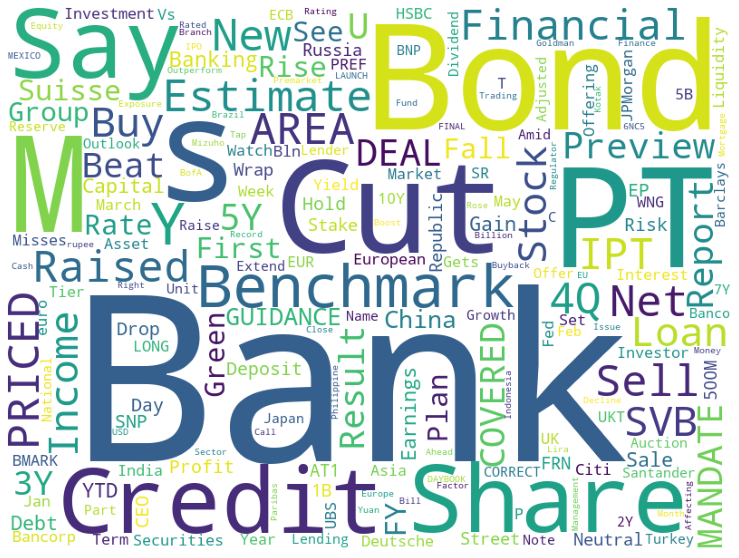

In [214]:
# prepare the text for wordcloud
chosen_col='headline_text' # name of the choosen column in df:text_data

all_docs=[]
all_docs.extend([x for x in text_data[chosen_col]])
# print('all value of ',chosen_col,':\n',all_docs)
# save all word in wc_text variable, and then use it in wordcloud
wc_text=" "
for x in all_docs:
    wc_text=wc_text+x+" "
# print('processed ',chosen_col,' for wordclooud:\n',wc_text)

# generate wordcloud
cloud =WordCloud(
    background_color="white",\
    collocations=False, \
    width=800, height=600, \
    margin=2,\
    contour_color = 'steelblue'
    ).generate(wc_text)

# # export its img
# cloud.to_file('wordcloud.jpg')

# show the wordcloud here
plt.figure(figsize=(20, 10))
plt.imshow(cloud)
plt.axis('off')
plt.show()

### way2: choose all final word from processed headline to generate wordcloud

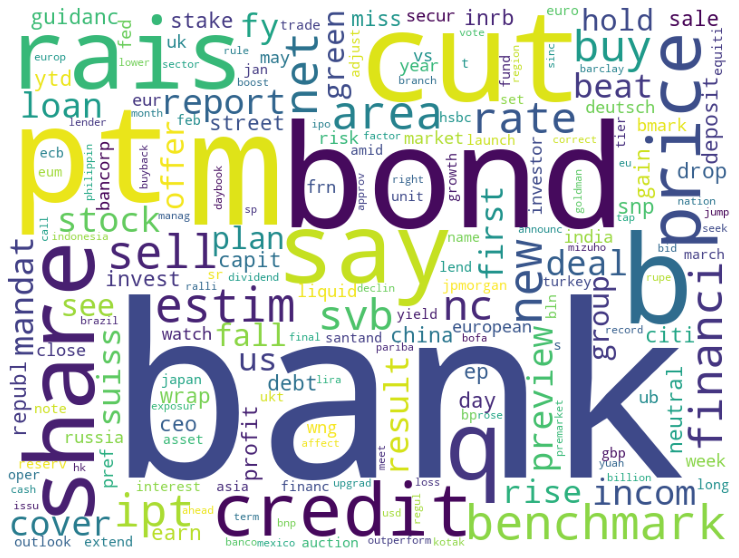

In [215]:
# prepare the text for wordcloud
chosen_col='words_final' # name of the choosen column in df:text_data

all_docs=[]
all_docs.extend([i for x in text_data[chosen_col] for i in x])
# print('all value of ',chosen_col,':\n',all_docs)
# save all word in wc_text variable, and then use it in wordcloud
wc_text=" "
for x in all_docs:
    wc_text=wc_text+x+" "
# print('processed ',chosen_col,' for wordclooud:\n',wc_text)

# generate wordcloud
cloud =WordCloud(
    background_color="white",\
    collocations=False, \
    width=800, height=600, \
    margin=2,\
    contour_color = 'steelblue'
    ).generate(wc_text)

# # export its img
# cloud.to_file('wordcloud.jpg')

# show the wordcloud here
plt.figure(figsize=(20, 10))
plt.imshow(cloud)
plt.axis('off')
plt.show()

## Trending Topic

In [195]:
svb

,svb
publish time,
2023-01-02,NaN
2023-01-03,225.22
2023-01-04,240.06
2023-01-05,232.59
2023-01-06,245.79
...,...
2023-03-27,106.04
2023-03-28,0.40
2023-03-29,0.97


In [196]:
def count_number_of_headline_within_top5(top_n_index=0,top5=top5):
    a = text_data[text_data['Topic'] == top5[top_n_index]].shape[0]
    print('the headine number with topic',top5[i],'ranked#',top_n_index+1,':',a)

for i in range(5):
    count_number_of_headline_within_top5(top_n_index=i,top5=top5)

the headine number with topic 7 ranked# 1 : 1210
the headine number with topic 1 ranked# 2 : 1169
the headine number with topic 9 ranked# 3 : 1089
the headine number with topic 6 ranked# 4 : 1035
the headine number with topic 3 ranked# 5 : 750


In [197]:
text_data[text_data['Topic']==top5[0]].head()

,headline_text,Sentence_length,doc,words,words_no_stop,words_final,words_frequency,Topic
publish time,,,,,,,,
2023-01-02,Paschi Jumps; Bank Says Risks to Business Cont...,61,paschi jumps bank says risks to business conti...,"[paschi, jumps, bank, says, risks, to, busines...","[paschi, jumps, bank, says, risks, business, c...","[paschi, jump, bank, say, risk, busi, continu,...","[(1, 1), (68, 1), (69, 1), (70, 1), (71, 1), (...",7
2023-01-02,Paschi Says It Has Overcome Risks to Business ...,56,paschi says it has overcome risks to business ...,"[paschi, says, it, has, overcome, risks, to, b...","[paschi, says, overcome, risks, business, cont...","[paschi, say, overcom, risk, busi, continu]","[(68, 1), (69, 1), (71, 1), (72, 1), (73, 1), ...",7
2023-01-03,Poland’s Analyst-Favored Bank Stocks Start Yea...,60,polands analystfavored bank stocks start year ...,"[polands, analystfavored, bank, stocks, start,...","[polands, analystfavored, bank, stocks, start,...","[poland, analystfavor, bank, stock, start, yea...","[(1, 1), (191, 1), (192, 1), (193, 1), (194, 1...",7
2023-01-03,CSB Bank Leads Rally in Lenders on Strong Cred...,55,csb bank leads rally in lenders on strong cred...,"[csb, bank, leads, rally, in, lenders, on, str...","[csb, bank, leads, rally, lenders, strong, cre...","[csb, bank, lead, ralli, lender, strong, credi...","[(1, 1), (46, 1), (193, 1), (229, 1), (230, 1)...",7
2023-01-03,*BRADESCO'S SCARPELLI TO BE NEXT BANK CFO: VALOR,48,bradesco scarpelli to be next bank cfo valor,"[bradesco, scarpelli, to, be, next, bank, cfo,...","[bradesco, scarpelli, next, bank, cfo, valor]","[bradesco, scarpelli, next, bank, cfo, valor]","[(1, 1), (281, 1), (282, 1), (284, 1), (285, 1...",7


In [198]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def show_topi_topic(i):
    # SET THE KEY POINT
    value=top5[i]

    count_number_of_headline_within_top5(top_n_index=i,top5=top5)

    # new dataframe called LAD11
    text_data[ value ]=[1 if x==value else 0 for x in text_data['Topic']]
    LDA11=text_data[ [value] ].copy().resample('1D').sum()
    LDA11["svb"]=svb["svb"]
    print(LDA11.head())

    # DRAW THE LINE CHART
    # # Create figure with secondary y-axis

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Add traces
    fig.add_trace(
        go.Scatter(x=LDA11[value].index, y=LDA11[value], name='Frequency', mode='lines'),secondary_y=False)

    fig.add_trace(
        go.Scatter(x=LDA11['svb'].index, y=LDA11['svb'], name='SVB Stock Price', mode='lines',  line=dict(color='red')),secondary_y=True)

    # Add figure title
    fig.update_layout(
        title_text="Trending of topic "+str(value),
        width=1000,
        height=500,
    )

    # Set x-axis title
    fig.update_xaxes(title_text="Date")

    # Set y-axes titles
    fig.update_yaxes(title_text="frequency per minute ", secondary_y=False)
    fig.update_yaxes(title_text="<b> SVB </b>", secondary_y=True)

    fig.show()

In [199]:
show_topi_topic(i=0)

the headine number with topic 3 ranked# 1 : 1210
              7     svb
publish time           
2023-01-02    2     NaN
2023-01-03    3  225.22
2023-01-04    4  240.06
2023-01-05    8  232.59
2023-01-06    4  245.79


In [200]:
show_topi_topic(i=1)

the headine number with topic 3 ranked# 2 : 1169
              1     svb
publish time           
2023-01-02    0     NaN
2023-01-03    1  225.22
2023-01-04    4  240.06
2023-01-05    1  232.59
2023-01-06    1  245.79


In [201]:
show_topi_topic(i=2)

the headine number with topic 3 ranked# 3 : 1089
               9     svb
publish time            
2023-01-02     7     NaN
2023-01-03    52  225.22
2023-01-04    59  240.06
2023-01-05    25  232.59
2023-01-06     7  245.79


In [202]:
show_topi_topic(i=3)

the headine number with topic 3 ranked# 4 : 1035
               6     svb
publish time            
2023-01-02     0     NaN
2023-01-03    20  225.22
2023-01-04    18  240.06
2023-01-05    17  232.59
2023-01-06    16  245.79


In [203]:
show_topi_topic(i=4)

the headine number with topic 3 ranked# 5 : 750
              3     svb
publish time           
2023-01-02    2     NaN
2023-01-03    3  225.22
2023-01-04    7  240.06
2023-01-05    2  232.59
2023-01-06    2  245.79


print topic 10 news headline of 1st topic based on the topic probability.

In [204]:
topic1st=text_data[text_data["Topic"]==value]
topprob=[]
for l in range(len(topic1st)):
  topprob.append(sorted(ldamodel.get_document_topics(topic1st.iloc[l]["words_frequency"],minimum_probability=0),
                      key=lambda x:x[1],reverse=True)[0][1])
topic1st["Prob"]=topprob

In [205]:
topic1st.head(2)

,headline_text,Sentence_length,doc,words,words_no_stop,words_final,words_frequency,Topic,7,1,9,6,3,Prob
publish time,,,,,,,,,,,,,,
2023-01-02,Paschi Jumps; Bank Says Risks to Business Cont...,61,paschi jumps bank says risks to business conti...,"[paschi, jumps, bank, says, risks, to, busines...","[paschi, jumps, bank, says, risks, business, c...","[paschi, jump, bank, say, risk, busi, continu,...","[(1, 1), (68, 1), (69, 1), (70, 1), (71, 1), (...",7,1,0,0,0,0,0.447642
2023-01-02,Paschi Says It Has Overcome Risks to Business ...,56,paschi says it has overcome risks to business ...,"[paschi, says, it, has, overcome, risks, to, b...","[paschi, says, overcome, risks, business, cont...","[paschi, say, overcom, risk, busi, continu]","[(68, 1), (69, 1), (71, 1), (72, 1), (73, 1), ...",7,1,0,0,0,0,0.358824


In [206]:
set_n=10

top_headines=topic1st.sort_values("Prob",ascending=False).iloc[:set_n]
for i in range(set_n_top):
  print(top_headines.index[i],' ', top_headines.iloc[i,0])

2023-03-14 00:00:00   Regional Bank Stocks Lead Rally Across US Lenders After Selloff
2023-01-19 00:00:00   Japanese Banks Seen Resuming Rally on BOJ Shift: Street Wrap
2023-03-31 00:00:00   Japan Stocks Rebound, Tracking US Gains, as Banking Woes Recede
2023-03-28 00:00:00   US Stocks Eke Out Gain With Banking Sector Relief: Squawk Wrap
2023-03-28 00:00:00   US Stocks Eke Out Gain With Banking Sector Relief: Macro Squawk
2023-03-20 00:00:00   Russian Stock Index Defies Global Rout as Sberbank Leads Gains
2023-03-17 00:00:00   Barclays’ Cau Says Fears of Global Banking Crisis Feel Overblown
2023-03-14 00:00:00   US Premarket Movers: BuzzFeed, Lyft, Regional Bank Stocks, Uber
2023-02-15 00:00:00   Bank Stock Bulls Have Gone Far Too Quiet in Europe: Macro View
2023-03-22 00:00:00   US LEVLOANS CALENDAR: Agenda Remains Slim; BWICs Emerge Tuesday


## Visualization of Topics

In [210]:
for i in range(5):
    count_number_of_headline_within_top5(top_n_index=i,top5=top5)

the headine number with topic 7 ranked# 1 : 1210
the headine number with topic 1 ranked# 2 : 1169
the headine number with topic 9 ranked# 3 : 1089
the headine number with topic 6 ranked# 4 : 1035
the headine number with topic 3 ranked# 5 : 750


In [208]:
import pyLDAvis.gensim

pyLDAvis.enable_notebook()
pyLDAvis.gensim.prepare(ldamodel, words_frequency, dictionary)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.196855 -0.056947       1        1  12.491046
9     -0.127808 -0.083473       2        1  11.936766
1      0.001740  0.061764       3        1  11.669627
6     -0.002433  0.242346       4        1  10.838197
3      0.162179 -0.050571       5        1  10.029997
0     -0.062526 -0.008766       6        1   9.358213
5     -0.071974 -0.017252       7        1   8.871037
2     -0.084265 -0.067882       8        1   8.813877
4     -0.042441 -0.031530       9        1   8.255823
8      0.030672  0.012310      10        1   7.735418, topic_info=           Term         Freq        Total Category  logprob  loglift
36         bond   492.000000   492.000000  Default  30.0000  30.0000
1          bank  1788.000000  1788.000000  Default  29.0000  29.0000
96           pt   428.000000   428.000000  Default  28.0000  28.0000
94          cut   402.000000   402.000000  Default  27.0000  27.0000
46       credit   289.000000   289.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
74          say    60.122321   247.661400  Topic10  -4.3446   1.1437
1          bank   142.959852  1788.292494  Topic10  -3.4784   0.0329
337   unicredit    24.203035    36.964477  Topic10  -5.2545   2.1359
5591     collin    31.070241   192.255420  Topic10  -5.0048   0.7368
395          eu    23.493255    45.929512  Topic10  -5.2843   1.8890

[420 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
139      10  0.916672   aareal
944       6  0.047822       ab
944       7  0.812970       ab
1107      9  0.837242     absa
963      10  0.886806  account
...     ...       ...      ...
1491      3  0.958715      ytd
103       3  0.025330     yuan
103       5  0.911896     yuan
2436      6  0.852276  zealand
1489      2  0.960163    zloti

[574 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 10, 2, 7, 4, 1, 6, 3, 5, 9])

# *Export processed data

In [213]:
text_data.to_excel('topic modeling in processed data.xlsx')